# Notebook 2 – Feature Engineering por Complexo (REVISADO)

**Objetivo:** Agregar sessões de cinema 2023-2024 por REGISTRO_COMPLEXO e criar features para clusterização.

**Dataset de entrada:**
- `df_sessoes_fe_base.parquet` (74 colunas, 11.5M sessões, anos 2023-2025)

**Datasets de saída:**
- `df_complexos_features.parquet` (~900 complexos × ~60 features)
- `dicionario_features.json` (metadados das features)

**Abordagem:**
- Filtrar apenas anos cinematográficos 2023-2024 (728 dias)
- Agregar por REGISTRO_COMPLEXO
- Criar features numéricas, flags, entropias e features geográficas
- **NÃO normalizar/padronizar** (isso será feito no Notebook 3)
- Validar e exportar dataset completo para clusterização

---
## 1. Setup e Carregamento

In [1]:
import pandas as pd
import numpy as np
import json
from scipy.stats import entropy
import warnings
warnings.filterwarnings('ignore')

print("✓ Bibliotecas carregadas")

✓ Bibliotecas carregadas


In [ ]:
%load_ext watermark
%watermark -a "Guilherme Gustavo Roca Arenales" --iversions

In [ ]:
# ===== INÍCIO DO PROCESSAMENTO =====
print("\n" + "🎬"*35)
print(" "*20 + "PIPELINE DE PROCESSAMENTO")
print(" "*15 + "Dados Cinematográficos SCB/ANCINE 2023-2025")
print("🎬"*35 + "\n")

import time
from datetime import datetime

# Registrar horário de início
INICIO_PROCESSAMENTO = time.time()
INICIO_TIMESTAMP = datetime.now()

print(f"🕐 Início do processamento: {INICIO_TIMESTAMP.strftime('%d/%m/%Y %H:%M:%S')}")
print(f"📍 Notebook: 0_preparacao_completa.ipynb")
print(f"🎯 Objetivo: realizar feature engineering para análise e clusterização")
print("\n" + "="*70 + "\n")

In [2]:
# Carregar dataset base
print("Carregando df_sessoes_fe_base.parquet...")
df = pd.read_parquet('../Bases/df_sessoes_fe_base.parquet')

print(f"✓ Dataset carregado: {df.shape[0]:,} sessões × {df.shape[1]} colunas")
print(f"\nAnos cinematográficos disponíveis: {sorted([int(x) for x in df['ano_cinematografico'].unique()])}")
print(f"Período: {df['DATA_EXIBICAO'].min().strftime('%Y-%m-%d')} a {df['DATA_EXIBICAO'].max().strftime('%Y-%m-%d')}")
print(f"\nComplexos únicos: {df['REGISTRO_COMPLEXO'].nunique():,}")
print(f"Obras únicas: {df['CPB_ROE'].nunique():,}")

Carregando df_sessoes_fe_base.parquet...
✓ Dataset carregado: 11,612,077 sessões × 74 colunas

Anos cinematográficos disponíveis: [2023, 2024, 2025]
Período: 2023-01-05 a 2025-09-30

Complexos únicos: 931
Obras únicas: 2,197


---
## 2. Filtro Temporal (2023-2024)

In [3]:
# Filtrar apenas anos cinematográficos 2023 e 2024
print("Aplicando filtro temporal: anos cinematográficos 2023-2024...")
df_base = df[df['ano_cinematografico'].isin([2023, 2024])].copy()

print(f"\n✓ Dataset filtrado: {df_base.shape[0]:,} sessões")
print(f"Sessões removidas (2025): {len(df) - len(df_base):,}")
print(f"\nComplexos únicos: {df_base['REGISTRO_COMPLEXO'].nunique()}")
print(f"Obras únicas (CPB_ROE): {df_base['CPB_ROE'].nunique()}")
print(f"Dias únicos: {df_base['DATA_EXIBICAO'].nunique()}")

# Liberar memória
del df
import gc
gc.collect()

Aplicando filtro temporal: anos cinematográficos 2023-2024...

✓ Dataset filtrado: 8,331,966 sessões
Sessões removidas (2025): 3,280,111

Complexos únicos: 900
Obras únicas (CPB_ROE): 1572
Dias únicos: 728


10

---
## 3. Preparação: Ranking Nacional de Obras (Top 5%)

In [4]:
# Calcular público total por obra no período 2023-2024
print("Calculando ranking nacional de obras por público...")
publico_por_obra = df_base.groupby('CPB_ROE')['PUBLICO'].sum().reset_index()
publico_por_obra.columns = ['CPB_ROE', 'publico_total_obra']

# Calcular percentil 95 (top 5%)
p95_publico = publico_por_obra['publico_total_obra'].quantile(0.95)
print(f"\nP95 público (top 5%): {p95_publico:,.0f} ingressos")

# Criar flag
publico_por_obra['is_obra_top5'] = publico_por_obra['publico_total_obra'] >= p95_publico

print(f"Obras no top 5%: {publico_por_obra['is_obra_top5'].sum()}")
print(f"Total de obras: {len(publico_por_obra)}")

# Merge com dataset base
df_base = df_base.merge(publico_por_obra[['CPB_ROE', 'is_obra_top5']], on='CPB_ROE', how='left')
df_base['is_obra_top5'] = df_base['is_obra_top5'].fillna(False)

print(f"\n✓ Flag 'is_obra_top5' adicionada")

Calculando ranking nacional de obras por público...

P95 público (top 5%): 702,574 ingressos
Obras no top 5%: 79
Total de obras: 1572

✓ Flag 'is_obra_top5' adicionada


---
## 4. Funções Auxiliares

In [5]:
def calcular_entropia_shannon(series):
    """
    Calcula entropia de Shannon: H = -Σ(p_i × log(p_i))
    Entropia alta = maior diversidade
    """
    if len(series) == 0:
        return 0.0
    counts = series.value_counts()
    probs = counts / counts.sum()
    return entropy(probs, base=2)

def calcular_percentual_seguro(serie_bool):
    """Calcula percentual de True em série booleana"""
    if len(serie_bool) == 0:
        return 0.0
    return (serie_bool == True).sum() / len(serie_bool)

def calcular_percentual_categoria(series, categoria):
    """Calcula percentual de uma categoria específica"""
    if len(series) == 0:
        return 0.0
    return (series == categoria).sum() / len(series)

print("✓ Funções auxiliares definidas")

✓ Funções auxiliares definidas


---
## 5. Features de Volume e Atividade

In [6]:
print("Calculando features de volume e atividade...\n")

grouped = df_base.groupby('REGISTRO_COMPLEXO')

df_complexos = pd.DataFrame({
    'REGISTRO_COMPLEXO': grouped.size().index,
    'total_sessoes': grouped.size().values,
    'publico_total': grouped['PUBLICO'].sum().values,
    'dias_ativos': grouped['DATA_EXIBICAO'].nunique().values,
    'num_salas': grouped['REGISTRO_SALA'].nunique().values,
    'capacidade_total': grouped.apply(lambda x: x.drop_duplicates('REGISTRO_SALA')['ASSENTOS_SALA'].sum()).values,
})

# Features derivadas
DIAS_PERIODO = 728  # 364 × 2 anos

df_complexos['pct_dias_operando'] = df_complexos['dias_ativos'] / DIAS_PERIODO
df_complexos['sessoes_por_dia_sala'] = df_complexos['total_sessoes'] / (df_complexos['dias_ativos'] * df_complexos['num_salas'])
df_complexos['volume_log'] = np.log1p(df_complexos['total_sessoes'])
df_complexos['publico_total_log'] = np.log1p(df_complexos['publico_total'])

# Flag: baixa atividade
df_complexos['baixa_atividade'] = (df_complexos['total_sessoes'] < 150).astype(int)

print(f"✓ Features de volume criadas para {len(df_complexos)} complexos")

Calculando features de volume e atividade...

✓ Features de volume criadas para 900 complexos


---
## 6. Features de Distribuidoras

In [7]:
print("Calculando features de distribuidoras...\n")

dist_features = grouped.agg({
    'distribuidora_major': lambda x: calcular_percentual_seguro(x),
    'distribuidora_independente': lambda x: calcular_percentual_seguro(x),
    'distribuidora_porte': lambda x: x.mean() if x.notna().any() else np.nan,
    'distribuidora_informada': lambda x: calcular_percentual_seguro(x),
}).reset_index()

dist_features.columns = ['REGISTRO_COMPLEXO', 'pct_sessoes_major', 'pct_sessoes_distrib_independente', 
                          'porte_medio_distribuidora', 'pct_sessoes_com_distribuidor']

# Flag: tem distribuidor
tem_dist = grouped['distribuidora_informada'].apply(lambda x: (x == True).any()).reset_index()
tem_dist.columns = ['REGISTRO_COMPLEXO', 'tem_distribuidor']
dist_features['tem_distribuidor'] = tem_dist['tem_distribuidor'].astype(int)

df_complexos = df_complexos.merge(dist_features, on='REGISTRO_COMPLEXO', how='left')

print(f"✓ Features de distribuidoras criadas")

Calculando features de distribuidoras...

✓ Features de distribuidoras criadas


---
## 7. Features de Produtoras

In [8]:
print("Calculando features de produtoras...\n")

prod_features = grouped.agg({
    'produtora_independente': lambda x: calcular_percentual_seguro(x),
    'tem_produtora_brasileira': lambda x: calcular_percentual_seguro(x),
    'produtora_nivel_medio': lambda x: x.mean() if x.notna().any() else np.nan,
}).reset_index()

prod_features.columns = ['REGISTRO_COMPLEXO', 'pct_sessoes_produtora_independente', 
                          'pct_sessoes_tem_produtora_brasileira', 'produtora_nivel_medio_complexo']

df_complexos = df_complexos.merge(prod_features, on='REGISTRO_COMPLEXO', how='left')

print(f"✓ Features de produtoras criadas")

Calculando features de produtoras...

✓ Features de produtoras criadas


---
## 8. Features de Nacionalidade

In [9]:
print("Calculando features de nacionalidade...\n")

nac_features = grouped.agg({
    'NACIONALIDADE': [
        ('pct_sessoes_brasileiras', lambda x: calcular_percentual_categoria(x, 'Brasileira')),
        ('pct_sessoes_estrangeiras', lambda x: calcular_percentual_categoria(x, 'Estrangeira')),
        ('pct_sessoes_especiais', lambda x: calcular_percentual_categoria(x, 'Especial')),
    ]
}).reset_index()

nac_features.columns = ['REGISTRO_COMPLEXO', 'pct_sessoes_brasileiras', 'pct_sessoes_estrangeiras', 'pct_sessoes_especiais']

# Feature composta: brasileiras independentes
bras_ind = grouped.apply(
    lambda x: ((x['NACIONALIDADE'] == 'Brasileira') & (x['produtora_independente'] == True)).sum() / len(x)
).reset_index()
bras_ind.columns = ['REGISTRO_COMPLEXO', 'pct_sessoes_brasileiras_independentes']

nac_features = nac_features.merge(bras_ind, on='REGISTRO_COMPLEXO')
df_complexos = df_complexos.merge(nac_features, on='REGISTRO_COMPLEXO', how='left')

print(f"✓ Features de nacionalidade criadas")

Calculando features de nacionalidade...

✓ Features de nacionalidade criadas


---
## 9. Features de Modalidade

In [10]:
print("Calculando features de modalidade...\n")

mod_features = grouped.agg({
    'TIPO_SESSAO': [
        ('pct_modalidade_a', lambda x: calcular_percentual_categoria(x, 'Sessão Regular')),
        ('pct_modalidade_b', lambda x: calcular_percentual_categoria(x, 'Pré-Estreia')),
        ('pct_modalidade_c', lambda x: calcular_percentual_categoria(x, 'Mostra ou Festival')),
        ('pct_modalidade_d', lambda x: calcular_percentual_categoria(x, 'Sessão Privada')),
    ]
}).reset_index()

mod_features.columns = ['REGISTRO_COMPLEXO', 'pct_modalidade_a', 'pct_modalidade_b', 'pct_modalidade_c', 'pct_modalidade_d']
df_complexos = df_complexos.merge(mod_features, on='REGISTRO_COMPLEXO', how='left')

print(f"✓ Features de modalidade criadas")

Calculando features de modalidade...

✓ Features de modalidade criadas


---
## 10. Features de Legendas

In [11]:
print("Calculando features de legendas...\n")

leg_features = grouped.agg({
    'LEGENDADA': [
        ('pct_sessoes_legendadas', lambda x: calcular_percentual_categoria(x, 'SIM')),
        ('pct_sessoes_dubladas', lambda x: calcular_percentual_categoria(x, 'NÃO')),
    ]
}).reset_index()

leg_features.columns = ['REGISTRO_COMPLEXO', 'pct_sessoes_legendadas', 'pct_sessoes_dubladas']
df_complexos = df_complexos.merge(leg_features, on='REGISTRO_COMPLEXO', how='left')

print(f"✓ Features de legendas criadas")

Calculando features de legendas...

✓ Features de legendas criadas


---
## 11. Features de Concentração (Top 5%)

In [12]:
print("Calculando features de concentração em obras top 5%...\n")

top5_features = grouped.apply(lambda x: pd.Series({
    'pct_publico_obras_top5': x[x['is_obra_top5']]['PUBLICO'].sum() / x['PUBLICO'].sum() if x['PUBLICO'].sum() > 0 else 0,
    'pct_sessoes_obras_top5': (x['is_obra_top5']).sum() / len(x),
})).reset_index()

df_complexos = df_complexos.merge(top5_features, on='REGISTRO_COMPLEXO', how='left')

print(f"✓ Features de concentração criadas")

Calculando features de concentração em obras top 5%...

✓ Features de concentração criadas


---
## 12. Features Geográficas Básicas

In [13]:
print("Adicionando features geográficas básicas...\n")

geo_features = df_base.groupby('REGISTRO_COMPLEXO').first()[[
    'UF_SALA_COMPLEXO', 'MUNICIPIO_SALA_COMPLEXO', 'populacao', 'pib_per_capita'
]].reset_index()

geo_features.columns = ['REGISTRO_COMPLEXO', 'UF', 'municipio', 'populacao', 'pib_per_capita']
df_complexos = df_complexos.merge(geo_features, on='REGISTRO_COMPLEXO', how='left')

# Ingressos per capita
df_complexos['ingressos_per_capita_municipio'] = df_complexos['publico_total'] / df_complexos['populacao']

print(f"✓ Features geográficas básicas adicionadas")

Adicionando features geográficas básicas...

✓ Features geográficas básicas adicionadas


---
## 13. Features Geográficas Avançadas

In [14]:
print("Criando features geográficas avançadas...\n")

# 1. Flag: Capital estadual
capitais_estaduais = [
    'SÃO PAULO', 'RIO DE JANEIRO', 'BELO HORIZONTE', 'BRASÍLIA', 'SALVADOR',
    'FORTALEZA', 'CURITIBA', 'RECIFE', 'PORTO ALEGRE', 'MANAUS',
    'BELÉM', 'GOIÂNIA', 'SÃO LUÍS', 'MACEIÓ', 'NATAL', 'CAMPO GRANDE', 
    'TERESINA', 'JOÃO PESSOA', 'ARACAJU', 'CUIABÁ', 'FLORIANÓPOLIS',
    'VITÓRIA', 'PALMAS', 'BOA VISTA', 'PORTO VELHO', 'RIO BRANCO', 'MACAPÁ'
]

df_complexos['e_capital'] = df_complexos['municipio'].isin(capitais_estaduais).astype(int)

# 2. Porte do município
df_complexos['porte_municipio_cat'] = pd.cut(
    df_complexos['populacao'],
    bins=[0, 50000, 100000, 500000, 1000000, float('inf')],
    labels=['Pequeno', 'Medio', 'Grande', 'Muito_Grande', 'Metropole']
)

# 3. Faixa de renda per capita
df_complexos['faixa_renda_cat'] = pd.cut(
    df_complexos['pib_per_capita'],
    bins=[0, 30000, 50000, 70000, float('inf')],
    labels=['Baixa', 'Media_Baixa', 'Media_Alta', 'Alta']
)

print(f"✓ Features geográficas avançadas criadas")
print(f"  - Capitais: {df_complexos['e_capital'].sum()} complexos")

Criando features geográficas avançadas...

✓ Features geográficas avançadas criadas
  - Capitais: 301 complexos


---
## 14. Flags de Operação e Natureza Jurídica

In [15]:
print("Criando flags de operação e natureza jurídica...\n")

# 1. Flag: operação não comercial
operacao_info = df_base.groupby('REGISTRO_COMPLEXO')['OPERACAO_USUAL'].first().reset_index()
df_complexos = df_complexos.merge(operacao_info, on='REGISTRO_COMPLEXO', how='left')
df_complexos['operacao_nao_comercial'] = (df_complexos['OPERACAO_USUAL'] == 'NÃO COMERCIAL').astype(int)

# 2. Natureza jurídica agregada
natureza_info = df_base.groupby('REGISTRO_COMPLEXO')['NATUREZA_JURIDICA'].first().reset_index()
df_complexos = df_complexos.merge(natureza_info, on='REGISTRO_COMPLEXO', how='left')

df_complexos['natureza_publica'] = df_complexos['NATUREZA_JURIDICA'].apply(
    lambda x: 1 if pd.notna(x) and any(termo in str(x) for termo in ['Órgão Público', 'Autarquia', 'Fundação Pública']) else 0
)

df_complexos['natureza_economia_mista'] = (df_complexos['NATUREZA_JURIDICA'] == 'Sociedade de Economia Mista').astype(int)

df_complexos['natureza_terceiro_setor'] = df_complexos['NATUREZA_JURIDICA'].apply(
    lambda x: 1 if pd.notna(x) and any(termo in str(x) for termo in ['Associação', 'Fundação Privada', 'Serviço Social']) else 0
)

df_complexos['natureza_privada_com_fins_lucrativos'] = df_complexos['NATUREZA_JURIDICA'].apply(
    lambda x: 1 if pd.notna(x) and any(termo in str(x) for termo in ['Sociedade Empresária', 'Sociedade Anônima', 'Empresário', 'Empresa Individual']) else 0
)

df_complexos['natureza_nao_informada'] = df_complexos['NATUREZA_JURIDICA'].isna().astype(int)

# 3. Flag: operação intermitente
df_complexos['operacao_intermitente'] = (df_complexos['pct_dias_operando'] < 0.5).astype(int)

# 4. Flag: exibidor independente
grupo_info = df_base.groupby('REGISTRO_COMPLEXO')['REGISTRO_GRUPO_EXIBIDOR'].first().reset_index()
df_complexos = df_complexos.merge(grupo_info, on='REGISTRO_COMPLEXO', how='left')
df_complexos['exibidor_independente'] = df_complexos['REGISTRO_GRUPO_EXIBIDOR'].isna().astype(int)

# 5. Flag: exibidor irregular
irregular_info = df_base.groupby('REGISTRO_COMPLEXO')['EXIBIDOR_IRREGULAR'].first().reset_index()
df_complexos = df_complexos.merge(irregular_info, on='REGISTRO_COMPLEXO', how='left')
df_complexos['exibidor_irregular'] = df_complexos['EXIBIDOR_IRREGULAR'].fillna(False).astype(int)

# Limpar colunas auxiliares
df_complexos = df_complexos.drop(['OPERACAO_USUAL', 'NATUREZA_JURIDICA', 'REGISTRO_GRUPO_EXIBIDOR', 'EXIBIDOR_IRREGULAR'], axis=1)

print(f"✓ Flags criadas")
print(f"  - Operação não comercial: {df_complexos['operacao_nao_comercial'].sum()}")
print(f"  - Natureza pública: {df_complexos['natureza_publica'].sum()}")
print(f"  - Exibidor irregular: {df_complexos['exibidor_irregular'].sum()}")

Criando flags de operação e natureza jurídica...

✓ Flags criadas
  - Operação não comercial: 4
  - Natureza pública: 4
  - Exibidor irregular: 96


---
## 15. Entropias (Diversidade)

In [16]:
print("Calculando entropias de diversidade...\n")

# Entropia de Nacionalidade
entropia_nac = grouped['NACIONALIDADE'].apply(calcular_entropia_shannon).reset_index()
entropia_nac.columns = ['REGISTRO_COMPLEXO', 'entropia_nacionalidade']

# Entropia de Modalidade
entropia_mod = grouped['TIPO_SESSAO'].apply(calcular_entropia_shannon).reset_index()
entropia_mod.columns = ['REGISTRO_COMPLEXO', 'entropia_modalidade']

# Entropia de Faixa Horária
entropia_hora = grouped['FAIXA_HORARIA'].apply(calcular_entropia_shannon).reset_index()
entropia_hora.columns = ['REGISTRO_COMPLEXO', 'entropia_faixa_horaria']

# Entropia de Distribuidora (top 10 + 'Outras')
top10_dist = df_base['distribuidora_major_nome'].value_counts().head(10).index.tolist()
df_base['dist_categoria'] = df_base['distribuidora_major_nome'].apply(
    lambda x: x if x in top10_dist else 'Outras'
)
grouped_dist = df_base.groupby('REGISTRO_COMPLEXO')
entropia_dist = grouped_dist['dist_categoria'].apply(calcular_entropia_shannon).reset_index()
entropia_dist.columns = ['REGISTRO_COMPLEXO', 'entropia_distribuidora']

# Merge
df_complexos = df_complexos.merge(entropia_nac, on='REGISTRO_COMPLEXO', how='left')
df_complexos = df_complexos.merge(entropia_mod, on='REGISTRO_COMPLEXO', how='left')
df_complexos = df_complexos.merge(entropia_hora, on='REGISTRO_COMPLEXO', how='left')
df_complexos = df_complexos.merge(entropia_dist, on='REGISTRO_COMPLEXO', how='left')

print(f"✓ Entropias calculadas")

Calculando entropias de diversidade...

✓ Entropias calculadas


---
## 16. Feature de Diversidade Geográfica (Cinema Mundial)

In [17]:
print("Criando feature de diversidade geográfica (cinema mundial)...\n")

# 1. Classificar obras por origem geográfica
paises_anglo = ['ESTADOS UNIDOS', 'CANADÁ', 'REINO UNIDO', 'INGLATERRA']

obras_info = df_base.groupby('CPB_ROE').agg({
    'NACIONALIDADE': 'first',
    'PAIS_OBRA': 'first'
}).reset_index()

obras_info['e_cinema_mundial'] = (
    (obras_info['NACIONALIDADE'] != 'Brasileira') & 
    (~obras_info['PAIS_OBRA'].isin(paises_anglo))
)

# 2. Agregar por complexo (versão vetorizada)
obras_complexo_mundo = df_base.groupby(['REGISTRO_COMPLEXO', 'CPB_ROE']).size().reset_index()[['REGISTRO_COMPLEXO', 'CPB_ROE']]
obras_complexo_mundo = obras_complexo_mundo.merge(obras_info[['CPB_ROE', 'e_cinema_mundial']], on='CPB_ROE', how='left')

cinema_mundial_stats = obras_complexo_mundo.groupby('REGISTRO_COMPLEXO').agg({
    'CPB_ROE': 'count',
    'e_cinema_mundial': 'sum'
}).reset_index()
cinema_mundial_stats.columns = ['REGISTRO_COMPLEXO', 'total_obras', 'obras_cinema_mundial']
cinema_mundial_stats['pct_obras_cinema_mundial'] = cinema_mundial_stats['obras_cinema_mundial'] / cinema_mundial_stats['total_obras']

df_complexos = df_complexos.merge(
    cinema_mundial_stats[['REGISTRO_COMPLEXO', 'obras_cinema_mundial', 'pct_obras_cinema_mundial']], 
    on='REGISTRO_COMPLEXO', how='left'
)

print(f"✓ Feature criada: pct_obras_cinema_mundial")
print(f"  Complexos com cinema mundial: {(df_complexos['obras_cinema_mundial'] > 0).sum()}")

Criando feature de diversidade geográfica (cinema mundial)...

✓ Feature criada: pct_obras_cinema_mundial
  Complexos com cinema mundial: 863


---
## 17. Features de Obras Exclusivas e Ultranicho

In [18]:
print("Criando features de obras exclusivas e nicho...\n")

# 1. Identificar obras exclusivas (1 único complexo)
complexos_por_obra = df_base.groupby('CPB_ROE')['REGISTRO_COMPLEXO'].nunique().reset_index()
complexos_por_obra.columns = ['CPB_ROE', 'num_complexos']
complexos_por_obra['e_obra_exclusiva'] = (complexos_por_obra['num_complexos'] == 1)

# 2. Identificar obras ultranicho (≤3 sessões nacionais)
sessoes_por_obra = df_base.groupby('CPB_ROE')['DATA_EXIBICAO'].count().reset_index()
sessoes_por_obra.columns = ['CPB_ROE', 'sessoes_nacionais']
sessoes_por_obra['e_obra_ultranicho'] = sessoes_por_obra['sessoes_nacionais'] <= 3

# 3. Merge com df_base
df_base = df_base.merge(complexos_por_obra[['CPB_ROE', 'e_obra_exclusiva']], on='CPB_ROE', how='left')
df_base = df_base.merge(sessoes_por_obra[['CPB_ROE', 'e_obra_ultranicho']], on='CPB_ROE', how='left')

# 4. Agregar por complexo (versão vetorizada)
obras_stats = df_base.groupby(['REGISTRO_COMPLEXO', 'CPB_ROE']).agg({
    'e_obra_exclusiva': 'first',
    'e_obra_ultranicho': 'first'
}).reset_index()

resumo_complexo = obras_stats.groupby('REGISTRO_COMPLEXO').agg({
    'CPB_ROE': 'count',
    'e_obra_exclusiva': 'sum',
    'e_obra_ultranicho': 'sum'
}).reset_index()

resumo_complexo.columns = ['REGISTRO_COMPLEXO', 'total_obras', 'num_obras_exclusivas', 'num_obras_ultranicho']
resumo_complexo['pct_obras_exclusivas'] = resumo_complexo['num_obras_exclusivas'] / resumo_complexo['total_obras']
resumo_complexo['pct_obras_ultranicho'] = resumo_complexo['num_obras_ultranicho'] / resumo_complexo['total_obras']

# 5. Merge
df_complexos = df_complexos.merge(
    resumo_complexo[['REGISTRO_COMPLEXO', 'num_obras_exclusivas', 'pct_obras_exclusivas', 
                     'num_obras_ultranicho', 'pct_obras_ultranicho']], 
    on='REGISTRO_COMPLEXO', how='left'
)

df_complexos[['num_obras_exclusivas', 'pct_obras_exclusivas', 'num_obras_ultranicho', 'pct_obras_ultranicho']] = \
    df_complexos[['num_obras_exclusivas', 'pct_obras_exclusivas', 'num_obras_ultranicho', 'pct_obras_ultranicho']].fillna(0)

print(f"✓ Features criadas")
print(f"  - Complexos com obras exclusivas: {(df_complexos['num_obras_exclusivas'] > 0).sum()}")
print(f"  - Complexos com obras ultranicho: {(df_complexos['num_obras_ultranicho'] > 0).sum()}")

Criando features de obras exclusivas e nicho...

✓ Features criadas
  - Complexos com obras exclusivas: 103
  - Complexos com obras ultranicho: 86


---
## 18. Validação do Dataset Final

In [36]:
print("=" * 80)
print("VALIDAÇÃO DO DATASET FINAL")
print("=" * 80)

# 1. RESUMO GERAL
print(f"\n{'='*80}")
print(f"1. RESUMO GERAL")
print(f"{'='*80}")
print(f"  📊 Dimensões: {df_complexos.shape[0]} complexos × {df_complexos.shape[1]} features")
print(f"  📅 Período: Anos cinematográficos 2023-2024 (728 dias)")
print(f"  🎬 Total de sessões agregadas: {df_complexos['total_sessoes'].sum():,}")
print(f"  👥 Total de público agregado: {df_complexos['publico_total'].sum():,}")

# 2. FEATURES CRIADAS POR CATEGORIA (COM TIPO E DESCRIÇÃO)
print(f"\n{'='*80}")
print(f"2. FEATURES CRIADAS POR CATEGORIA")
print(f"{'='*80}")

# Dicionário de descrições
descricoes = {
    'REGISTRO_COMPLEXO': 'Identificador único do complexo',
    'total_sessoes': 'Total de sessões realizadas em 2023-2024',
    'publico_total': 'Público total acumulado no período',
    'volume_log': 'Transformação log do total de sessões',
    'publico_total_log': 'Transformação log do público total',
    'dias_ativos': 'Dias únicos com pelo menos uma sessão',
    'pct_dias_operando': 'Percentual de dias operando (de 728 possíveis)',
    'num_salas': 'Quantidade de salas do complexo',
    'capacidade_total': 'Soma dos assentos de todas as salas',
    'sessoes_por_dia_sala': 'Intensidade de uso (sessões/dias/salas)',
    'pct_sessoes_major': 'Percentual de sessões com majors (Warner, Disney, etc)',
    'pct_sessoes_distrib_independente': 'Percentual com distribuidoras independentes',
    'porte_medio_distribuidora': 'Porte médio (1-5, baseado em lançamentos)',
    'pct_sessoes_com_distribuidor': 'Percentual com informação de distribuidor',
    'tem_distribuidor': 'Flag: possui distribuidor identificado',
    'pct_sessoes_produtora_independente': 'Percentual com produtora independente BR (nível ≤2)',
    'pct_sessoes_tem_produtora_brasileira': 'Percentual com produtora brasileira identificada',
    'produtora_nivel_medio_complexo': 'Nível médio das produtoras BR (1-5, ANCINE)',
    'pct_sessoes_brasileiras': 'Percentual de obras brasileiras',
    'pct_sessoes_estrangeiras': 'Percentual de obras estrangeiras',
    'pct_sessoes_especiais': 'Percentual de obras especiais (eventos, ópera)',
    'pct_sessoes_brasileiras_independentes': 'Percentual brasileiras E independentes',
    'pct_modalidade_a': 'Percentual de Sessões Regulares',
    'pct_modalidade_b': 'Percentual de Pré-Estreias',
    'pct_modalidade_c': 'Percentual de Mostras/Festivais (sinal de cinema de arte)',
    'pct_modalidade_d': 'Percentual de Sessões Privadas',
    'pct_sessoes_legendadas': 'Percentual de sessões legendadas',
    'pct_sessoes_dubladas': 'Percentual de sessões dubladas',
    'pct_publico_obras_top5': 'Percentual do público em obras top 5% nacional',
    'pct_sessoes_obras_top5': 'Percentual de sessões em obras top 5%',
    'UF': 'Unidade Federativa (estado)',
    'municipio': 'Município do complexo',
    'populacao': 'População do município (IBGE)',
    'pib_per_capita': 'PIB per capita do município (IBGE)',
    'ingressos_per_capita_municipio': 'Ingressos vendidos por habitante',
    'e_capital': 'Flag: localizado em capital estadual',
    'porte_municipio_cat': 'Porte (Pequeno/Medio/Grande/Muito_Grande/Metropole)',
    'faixa_renda_cat': 'Faixa de PIB per capita (Baixa/Media_Baixa/Media_Alta/Alta)',
    'baixa_atividade': 'Flag: menos de 150 sessões no período',
    'tem_distribuidor': 'Flag: possui distribuidor identificado',
    'operacao_nao_comercial': 'Flag: operação não comercial (gratuito/cultural)',
    'natureza_publica': 'Flag: órgão público, autarquia ou fundação pública',
    'natureza_economia_mista': 'Flag: sociedade de economia mista',
    'natureza_terceiro_setor': 'Flag: associação, fundação privada ou serviço social',
    'natureza_privada_com_fins_lucrativos': 'Flag: empresa privada comercial',
    'natureza_nao_informada': 'Flag: natureza jurídica não informada',
    'operacao_intermitente': 'Flag: opera menos de 50% dos dias',
    'exibidor_independente': 'Flag: não pertence a grupo/rede',
    'exibidor_irregular': 'Flag: cadastro irregular na ANCINE',
    'entropia_nacionalidade': 'Diversidade de nacionalidades (Shannon)',
    'entropia_modalidade': 'Diversidade de tipos de sessão',
    'entropia_faixa_horaria': 'Diversidade de horários de exibição',
    'entropia_distribuidora': 'Diversidade de distribuidoras (top 10 + outras)',
    'obras_cinema_mundial': 'Número de obras não-anglo e não-brasileiras',
    'pct_obras_cinema_mundial': 'Percentual de cinema mundial (diversidade geográfica)',
    'num_obras_exclusivas': 'Obras exibidas APENAS neste complexo (curadoria)',
    'pct_obras_exclusivas': 'Percentual de obras exclusivas',
    'num_obras_ultranicho': 'Obras com ≤3 sessões a nível nacional',
    'pct_obras_ultranicho': 'Percentual de obras ultranicho',
}

categorias = {
    'Volume e Atividade': ['total_sessoes', 'publico_total', 'volume_log', 'publico_total_log', 
                           'dias_ativos', 'pct_dias_operando', 'num_salas', 'capacidade_total', 'sessoes_por_dia_sala'],
    'Distribuidoras': ['pct_sessoes_major', 'pct_sessoes_distrib_independente', 'porte_medio_distribuidora', 
                       'pct_sessoes_com_distribuidor', 'tem_distribuidor'],
    'Produtoras': ['pct_sessoes_produtora_independente', 'pct_sessoes_tem_produtora_brasileira', 'produtora_nivel_medio_complexo'],
    'Nacionalidade': ['pct_sessoes_brasileiras', 'pct_sessoes_estrangeiras', 'pct_sessoes_especiais', 'pct_sessoes_brasileiras_independentes'],
    'Modalidade': ['pct_modalidade_a', 'pct_modalidade_b', 'pct_modalidade_c', 'pct_modalidade_d'],
    'Legendas': ['pct_sessoes_legendadas', 'pct_sessoes_dubladas'],
    'Concentração': ['pct_publico_obras_top5', 'pct_sessoes_obras_top5'],
    'Geografia': ['UF', 'municipio', 'populacao', 'pib_per_capita', 'ingressos_per_capita_municipio',
                  'e_capital', 'porte_municipio_cat', 'faixa_renda_cat'],
    'Flags Operacionais': ['baixa_atividade', 'operacao_nao_comercial', 'natureza_publica', 'natureza_economia_mista',
                           'natureza_terceiro_setor', 'natureza_privada_com_fins_lucrativos', 'natureza_nao_informada',
                           'operacao_intermitente', 'exibidor_independente', 'exibidor_irregular'],
    'Diversidade (Entropias)': ['entropia_nacionalidade', 'entropia_modalidade', 'entropia_faixa_horaria', 'entropia_distribuidora'],
    'Cinema Mundial': ['obras_cinema_mundial', 'pct_obras_cinema_mundial'],
    'Obras Exclusivas/Nicho': ['num_obras_exclusivas', 'pct_obras_exclusivas', 'num_obras_ultranicho', 'pct_obras_ultranicho'],
}

for cat, feats in categorias.items():
    print(f"\n  📁 {cat}: {len(feats)} features")
    for feat in feats:
        if feat in df_complexos.columns:
            tipo = str(df_complexos[feat].dtype)
            desc = descricoes.get(feat, '---')
            print(f"     ✓ {feat:45s} ({tipo:10s}) - {desc}")
        else:
            print(f"     ✗ {feat:45s} - AUSENTE!")

# 3. VALORES NULOS
print(f"\n{'='*80}")
print(f"3. VALORES NULOS")
print(f"{'='*80}")

nulls = df_complexos.isnull().sum()
nulls_filtered = nulls[nulls > 0]

if len(nulls_filtered) > 0:
    print(f"\n  ⚠️  {len(nulls_filtered)} coluna com valores nulos:\n")
    for col in nulls_filtered.index:
        n = int(nulls_filtered[col])
        pct = (n / len(df_complexos)) * 100
        print(f"     • {col}: {n} nulos ({pct:.2f}%)")
    
    if 'produtora_nivel_medio_complexo' in nulls_filtered.index:
        print(f"\n  💡 Contexto:")
        print(f"     → Complexos sem NENHUMA obra com produtora BR identificada")
        print(f"     → Programação 100% estrangeira ou sem dados")
else:
    print(f"\n  ✅ Nenhuma coluna com valores nulos!")

# 4. VALIDAÇÃO DE RANGES
print(f"\n{'='*80}")
print(f"4. VALIDAÇÃO DE RANGES")
print(f"{'='*80}")

pct_cols = [col for col in df_complexos.columns if col.startswith('pct_')]
problemas = []
for col in pct_cols:
    min_val = df_complexos[col].min()
    max_val = df_complexos[col].max()
    if min_val < 0 or max_val > 1:
        problemas.append(f"  ⚠️  {col}: [{min_val:.4f}, {max_val:.4f}]")

if problemas:
    print(f"\n  ❌ Problemas encontrados:")
    for p in problemas:
        print(p)
else:
    print(f"\n  ✅ Todas as {len(pct_cols)} features percentuais no range [0, 1]")

# 5. ESTATÍSTICAS-CHAVE
print(f"\n{'='*80}")
print(f"5. ESTATÍSTICAS-CHAVE")
print(f"{'='*80}")

print(f"\n  📊 Volume:")
print(f"     • Sessões: {df_complexos['total_sessoes'].mean():.0f} média | {df_complexos['total_sessoes'].median():.0f} mediana")
print(f"     • Público: {df_complexos['publico_total'].mean():.0f} média | {df_complexos['publico_total'].median():.0f} mediana")
print(f"     • Dias ativos: {df_complexos['dias_ativos'].mean():.0f}/728 ({df_complexos['pct_dias_operando'].mean()*100:.1f}%)")

print(f"\n  🎬 Perfil:")
print(f"     • Cinema BR: {df_complexos['pct_sessoes_brasileiras'].mean()*100:.1f}% | Cap: {df_complexos[df_complexos['e_capital']==1]['pct_sessoes_brasileiras'].mean()*100:.1f}% vs Int: {df_complexos[df_complexos['e_capital']==0]['pct_sessoes_brasileiras'].mean()*100:.1f}%")
print(f"     • Majors: {df_complexos['pct_sessoes_major'].mean()*100:.1f}% | Cap: {df_complexos[df_complexos['e_capital']==1]['pct_sessoes_major'].mean()*100:.1f}% vs Int: {df_complexos[df_complexos['e_capital']==0]['pct_sessoes_major'].mean()*100:.1f}%")
print(f"     • Cinema mundial: {df_complexos['pct_obras_cinema_mundial'].mean()*100:.1f}% | {(df_complexos['obras_cinema_mundial'] > 0).sum()} complexos exibem")

print(f"\n  🎯 Diversidade:")
print(f"     • Obras exclusivas: {(df_complexos['num_obras_exclusivas'] > 0).sum()} complexos ({(df_complexos['num_obras_exclusivas'] > 0).mean()*100:.1f}%)")

print(f"\n  🏢 Operação:")
print(f"     • Baixa atividade: {df_complexos['baixa_atividade'].sum()} ({df_complexos['baixa_atividade'].mean()*100:.1f}%)")
print(f"     • Independentes: {df_complexos['exibidor_independente'].sum()} ({df_complexos['exibidor_independente'].mean()*100:.1f}%)")
print(f"     • Irregulares: {df_complexos['exibidor_irregular'].sum()} ({df_complexos['exibidor_irregular'].mean()*100:.1f}%)")

print(f"\n{'='*80}")
print(f"✅ VALIDAÇÃO CONCLUÍDA - Dataset pronto para Notebook 3!")
print(f"{'='*80}")

VALIDAÇÃO DO DATASET FINAL

1. RESUMO GERAL
  📊 Dimensões: 900 complexos × 58 features
  📅 Período: Anos cinematográficos 2023-2024 (728 dias)
  🎬 Total de sessões agregadas: 8,331,966
  👥 Total de público agregado: 241,919,809

2. FEATURES CRIADAS POR CATEGORIA

  📁 Volume e Atividade: 9 features
     ✓ total_sessoes                                 (int64     ) - Total de sessões realizadas em 2023-2024
     ✓ publico_total                                 (int64     ) - Público total acumulado no período
     ✓ volume_log                                    (float64   ) - Transformação log do total de sessões
     ✓ publico_total_log                             (float64   ) - Transformação log do público total
     ✓ dias_ativos                                   (int64     ) - Dias únicos com pelo menos uma sessão
     ✓ pct_dias_operando                             (float64   ) - Percentual de dias operando (de 728 possíveis)
     ✓ num_salas                                     (int64

In [38]:
from IPython.display import display
import pandas as pd

print("=" * 80)
print("PREVIEW DO DATASET")
print("=" * 80)

# 1. HEAD TRANSPOSTO com estilo
print(f"\n{'='*80}")
print("PRIMEIRAS 5 LINHAS (transpostas para visualização completa)")
print(f"{'='*80}\n")

df_head_t = df_complexos.head(5).T
df_head_t.columns = [f'Complexo_{i+1}' for i in range(5)]

display(df_head_t.style\
    .format(precision=2)\
    .set_properties(**{'text-align': 'left', 'font-size': '9pt'})\
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#2196F3'), ('color', 'white'), ('font-weight', 'bold'), ('text-align', 'center')]},
        {'selector': 'td', 'props': [('border', '1px solid #ddd')]},
    ]))

# 2. Estatísticas principais
print(f"\n{'='*80}")
print("ESTATÍSTICAS DAS FEATURES NUMÉRICAS PRINCIPAIS")
print(f"{'='*80}\n")

features_chave = [
    'total_sessoes', 'publico_total', 'dias_ativos', 'num_salas',
    'pct_sessoes_brasileiras', 'pct_sessoes_major', 'pct_obras_cinema_mundial',
    'pct_publico_obras_top5', 'num_obras_exclusivas', 'entropia_nacionalidade'
]

estat = df_complexos[features_chave].describe().T[['count', 'mean', 'std', 'min', '50%', 'max']]

display(estat.style\
    .format(precision=2)\
    .background_gradient(cmap='Blues', subset=['mean', '50%'])\
    .set_properties(**{'text-align': 'center'})\
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#4CAF50'), ('color', 'white'), ('font-weight', 'bold')]},
    ]))

# 3. Casos interessantes
print(f"\n{'='*80}")
print("CASOS INTERESSANTES")
print(f"{'='*80}")

print("\n🎨 TOP 5 - Maior diversidade (cinema mundial):")
top_mundo = df_complexos.nlargest(5, 'pct_obras_cinema_mundial')[
    ['municipio', 'UF', 'pct_obras_cinema_mundial', 'num_obras_exclusivas', 
     'pct_sessoes_brasileiras', 'total_sessoes']
]
display(top_mundo.style.format(precision=3).hide(axis='index'))

print("\n📚 TOP 5 - Cinemas curadores (obras exclusivas):")
top_curadores = df_complexos.nlargest(5, 'num_obras_exclusivas')[
    ['municipio', 'UF', 'num_obras_exclusivas', 'pct_obras_cinema_mundial',
     'pct_sessoes_brasileiras', 'total_sessoes']
]
display(top_curadores.style.format(precision=3).hide(axis='index'))

print("\n🇧🇷 TOP 5 - Maior foco em cinema brasileiro:")
top_br = df_complexos.nlargest(5, 'pct_sessoes_brasileiras')[
    ['municipio', 'UF', 'pct_sessoes_brasileiras', 'pct_sessoes_major',
     'num_obras_exclusivas', 'total_sessoes']
]
display(top_br.style.format(precision=3).hide(axis='index'))

print("\n🎬 TOP 5 - Maior volume (mainstream):")
top_volume = df_complexos.nlargest(5, 'total_sessoes')[
    ['municipio', 'UF', 'total_sessoes', 'publico_total', 'num_salas', 'pct_sessoes_major']
]
display(top_volume.style.format({'total_sessoes': '{:,.0f}', 'publico_total': '{:,.0f}', 
                                  'num_salas': '{:.0f}', 'pct_sessoes_major': '{:.3f}'}).hide(axis='index'))

print(f"\n{'='*80}")

PREVIEW DO DATASET

PRIMEIRAS 5 LINHAS (transpostas para visualização completa)



,Complexo_1,Complexo_2,Complexo_3,Complexo_4,Complexo_5
REGISTRO_COMPLEXO,11752,11818,11840,12006,12036
total_sessoes,10140,2575,24156,2086,10135
publico_total,425879,64710,1218521,44747,63458
dias_ativos,724,606,728,633,671
num_salas,4,2,9,1,4
capacidade_total,554,304,1810,145,588
pct_dias_operando,0.99,0.83,1.00,0.87,0.92
sessoes_por_dia_sala,3.50,2.12,3.69,3.30,3.78
volume_log,9.22,7.85,10.09,7.64,9.22
publico_total_log,12.96,11.08,14.01,10.71,11.06



ESTATÍSTICAS DAS FEATURES NUMÉRICAS PRINCIPAIS



,count,mean,std,min,50%,max
total_sessoes,900.00,9257.74,7606.30,3.00,7613.00,42864.00
publico_total,900.00,268799.79,304321.06,0.00,135421.00,1950418.00
dias_ativos,900.00,602.53,210.51,2.00,720.50,728.00
num_salas,900.00,4.11,2.68,1.00,4.00,18.00
pct_sessoes_brasileiras,900.00,0.13,0.10,0.00,0.11,1.00
pct_sessoes_major,900.00,0.73,0.17,0.00,0.76,1.00
pct_obras_cinema_mundial,900.00,0.13,0.08,0.00,0.13,0.56
pct_publico_obras_top5,900.00,0.82,0.21,0.00,0.88,1.00
num_obras_exclusivas,900.00,0.48,2.69,0.00,0.00,39.00
entropia_nacionalidade,900.00,0.54,0.24,0.00,0.52,1.57



CASOS INTERESSANTES

🎨 TOP 5 - Maior diversidade (cinema mundial):


...

municipio,UF,num_obras_exclusivas,pct_obras_cinema_mundial,pct_sessoes_brasileiras,total_sessoes
SÃO PAULO,SP,39,0.333,0.104,1795
PORTO ALEGRE,RS,30,0.449,0.386,3712
SÃO PAULO,SP,28,0.174,0.642,735
CURITIBA,PR,23,0.267,0.295,4719
BRASÍLIA,DF,21,0.264,0.409,1866



🇧🇷 TOP 5 - Maior foco em cinema brasileiro:


municipio,UF,pct_sessoes_brasileiras,pct_sessoes_major,num_obras_exclusivas,total_sessoes
ARCOS,MG,1.000,0.000,0,22
SANTO ANTÔNIO DO MONTE,MG,1.000,0.000,0,97
FORMIGA,MG,1.000,0.000,0,6
PAINS,MG,1.000,0.000,0,32
PORTO ALEGRE,RS,0.982,0.000,0,1416



🎬 TOP 5 - Maior volume (mainstream):


municipio,UF,total_sessoes,publico_total,num_salas,pct_sessoes_major
RIO DE JANEIRO,RJ,"42,864","1,622,946",18,0.705
GUARULHOS,SP,"41,414","1,950,418",15,0.708
CAMPINAS,SP,"39,565","1,533,015",15,0.733
SÃO PAULO,SP,"36,335","1,723,711",13,0.729
BRASÍLIA,DF,"35,461","1,079,413",13,0.703


---
## 19. Exportação dos Resultados

In [20]:
print("\nExportando resultados...\n")

# 1. Salvar dataset de complexos
output_path_parquet = '../Bases/df_complexos_features.parquet'
df_complexos.to_parquet(output_path_parquet, index=False)
print(f"✓ Dataset salvo: {output_path_parquet}")
print(f"  Shape: {df_complexos.shape}")

# 2. Criar dicionário de features
print(f"\nCriando dicionário de features...")

metadata = {
    # Identificação
    'REGISTRO_COMPLEXO': {'tipo': 'object', 'descricao': 'Código único do complexo', 'categoria': 'identificacao'},
    'UF': {'tipo': 'object', 'descricao': 'Unidade Federativa', 'categoria': 'geografia'},
    'municipio': {'tipo': 'object', 'descricao': 'Município do complexo', 'categoria': 'geografia'},
    
    # Volume
    'total_sessoes': {'tipo': 'int64', 'descricao': 'Número total de sessões 2023-2024', 'formula': 'count(sessoes)', 'categoria': 'volume'},
    'publico_total': {'tipo': 'int64', 'descricao': 'Público total acumulado', 'formula': 'sum(PUBLICO)', 'categoria': 'volume'},
    'volume_log': {'tipo': 'float64', 'descricao': 'Log(total_sessoes + 1)', 'formula': 'log1p(total_sessoes)', 'categoria': 'volume'},
    'publico_total_log': {'tipo': 'float64', 'descricao': 'Log(publico_total + 1)', 'formula': 'log1p(publico_total)', 'categoria': 'volume'},
    
    # Atividade
    'dias_ativos': {'tipo': 'int64', 'descricao': 'Dias únicos com sessões', 'formula': 'nunique(DATA_EXIBICAO)', 'categoria': 'atividade'},
    'pct_dias_operando': {'tipo': 'float64', 'descricao': '% de dias com operação', 'formula': 'dias_ativos / 728', 'categoria': 'atividade'},
    'num_salas': {'tipo': 'int64', 'descricao': 'Número de salas', 'formula': 'nunique(REGISTRO_SALA)', 'categoria': 'estrutura'},
    'capacidade_total': {'tipo': 'int64', 'descricao': 'Capacidade total de assentos', 'categoria': 'estrutura'},
    'sessoes_por_dia_sala': {'tipo': 'float64', 'descricao': 'Sessões por dia por sala', 'formula': 'total_sessoes / (dias_ativos × num_salas)', 'categoria': 'atividade'},
    
    # Distribuidoras
    'pct_sessoes_major': {'tipo': 'float64', 'descricao': '% sessões com majors', 'categoria': 'distribuidora'},
    'pct_sessoes_distrib_independente': {'tipo': 'float64', 'descricao': '% sessões com distribuidoras independentes', 'categoria': 'distribuidora'},
    'porte_medio_distribuidora': {'tipo': 'float64', 'descricao': 'Porte médio (1-5)', 'categoria': 'distribuidora'},
    'pct_sessoes_com_distribuidor': {'tipo': 'float64', 'descricao': '% sessões com distribuidor identificado', 'categoria': 'distribuidora'},
    'tem_distribuidor': {'tipo': 'int64', 'descricao': 'Flag: tem distribuidor identificado', 'categoria': 'flag'},
    
    # Produtoras
    'pct_sessoes_produtora_independente': {'tipo': 'float64', 'descricao': '% sessões com produtora independente BR', 'categoria': 'produtora'},
    'pct_sessoes_tem_produtora_brasileira': {'tipo': 'float64', 'descricao': '% sessões com produtora brasileira', 'categoria': 'produtora'},
    'produtora_nivel_medio_complexo': {'tipo': 'float64', 'descricao': 'Nível médio produtoras BR (1-5)', 'categoria': 'produtora'},
    
    # Nacionalidade
    'pct_sessoes_brasileiras': {'tipo': 'float64', 'descricao': '% sessões com obras brasileiras', 'categoria': 'perfil'},
    'pct_sessoes_estrangeiras': {'tipo': 'float64', 'descricao': '% sessões com obras estrangeiras', 'categoria': 'perfil'},
    'pct_sessoes_especiais': {'tipo': 'float64', 'descricao': '% sessões com obras especiais', 'categoria': 'perfil'},
    'pct_sessoes_brasileiras_independentes': {'tipo': 'float64', 'descricao': '% sessões BR independentes', 'categoria': 'perfil'},
    
    # Modalidade
    'pct_modalidade_a': {'tipo': 'float64', 'descricao': '% Sessões Regulares', 'categoria': 'perfil'},
    'pct_modalidade_b': {'tipo': 'float64', 'descricao': '% Pré-Estreias', 'categoria': 'perfil'},
    'pct_modalidade_c': {'tipo': 'float64', 'descricao': '% Mostras/Festivais (forte sinal arte)', 'categoria': 'perfil'},
    'pct_modalidade_d': {'tipo': 'float64', 'descricao': '% Sessões Privadas', 'categoria': 'perfil'},
    
    # Legendas
    'pct_sessoes_legendadas': {'tipo': 'float64', 'descricao': '% sessões legendadas', 'categoria': 'perfil'},
    'pct_sessoes_dubladas': {'tipo': 'float64', 'descricao': '% sessões dubladas', 'categoria': 'perfil'},
    
    # Concentração
    'pct_publico_obras_top5': {'tipo': 'float64', 'descricao': '% público em obras top 5% nacional', 'categoria': 'concentracao'},
    'pct_sessoes_obras_top5': {'tipo': 'float64', 'descricao': '% sessões em obras top 5%', 'categoria': 'concentracao'},
    
    # Geografia
    'populacao': {'tipo': 'float64', 'descricao': 'População do município (IBGE)', 'categoria': 'geografia'},
    'pib_per_capita': {'tipo': 'float64', 'descricao': 'PIB per capita (IBGE)', 'categoria': 'geografia'},
    'ingressos_per_capita_municipio': {'tipo': 'float64', 'descricao': 'Ingressos por habitante', 'formula': 'publico_total / populacao', 'categoria': 'geografia'},
    'e_capital': {'tipo': 'int64', 'descricao': 'Flag: capital estadual', 'categoria': 'geografia'},
    'porte_municipio_cat': {'tipo': 'category', 'descricao': 'Porte do município', 'categoria': 'geografia'},
    'faixa_renda_cat': {'tipo': 'category', 'descricao': 'Faixa de renda per capita', 'categoria': 'geografia'},
    
    # Flags operação
    'baixa_atividade': {'tipo': 'int64', 'descricao': 'Flag: < 150 sessões em 2 anos', 'categoria': 'flag'},
    'operacao_intermitente': {'tipo': 'int64', 'descricao': 'Flag: opera < 50% dos dias', 'categoria': 'flag'},
    'exibidor_independente': {'tipo': 'int64', 'descricao': 'Flag: sem grupo exibidor', 'categoria': 'flag'},
    'exibidor_irregular': {'tipo': 'int64', 'descricao': 'Flag: cadastro irregular ANCINE', 'categoria': 'flag'},
    'operacao_nao_comercial': {'tipo': 'int64', 'descricao': 'Flag: operação não comercial', 'categoria': 'flag'},
    'natureza_publica': {'tipo': 'int64', 'descricao': 'Flag: natureza jurídica pública', 'categoria': 'flag'},
    'natureza_economia_mista': {'tipo': 'int64', 'descricao': 'Flag: sociedade economia mista', 'categoria': 'flag'},
    'natureza_terceiro_setor': {'tipo': 'int64', 'descricao': 'Flag: associação/fundação/serviço social', 'categoria': 'flag'},
    'natureza_privada_com_fins_lucrativos': {'tipo': 'int64', 'descricao': 'Flag: empresa privada comercial', 'categoria': 'flag'},
    'natureza_nao_informada': {'tipo': 'int64', 'descricao': 'Flag: natureza jurídica não informada', 'categoria': 'flag'},
    
    # Entropias
    'entropia_nacionalidade': {'tipo': 'float64', 'descricao': 'Diversidade de nacionalidades (Shannon)', 'categoria': 'diversidade'},
    'entropia_modalidade': {'tipo': 'float64', 'descricao': 'Diversidade de modalidades', 'categoria': 'diversidade'},
    'entropia_faixa_horaria': {'tipo': 'float64', 'descricao': 'Diversidade de horários', 'categoria': 'diversidade'},
    'entropia_distribuidora': {'tipo': 'float64', 'descricao': 'Diversidade de distribuidoras', 'categoria': 'diversidade'},
    
    # Diversidade geográfica
    'obras_cinema_mundial': {'tipo': 'int64', 'descricao': 'Número de obras não-anglo/não-BR', 'categoria': 'diversidade'},
    'pct_obras_cinema_mundial': {'tipo': 'float64', 'descricao': '% obras cinema mundial (não EUA/CAN/UK/BR)', 'categoria': 'diversidade'},
    
    # Obras exclusivas e nicho
    'num_obras_exclusivas': {'tipo': 'int64', 'descricao': 'Obras exibidas em apenas 1 complexo', 'categoria': 'nicho'},
    'pct_obras_exclusivas': {'tipo': 'float64', 'descricao': '% obras exclusivas', 'categoria': 'nicho'},
    'num_obras_ultranicho': {'tipo': 'int64', 'descricao': 'Obras com ≤3 sessões nacionais', 'categoria': 'nicho'},
    'pct_obras_ultranicho': {'tipo': 'float64', 'descricao': '% obras ultranicho', 'categoria': 'nicho'},
}

# Adicionar tipos de dados reais
for col in df_complexos.columns:
    if col in metadata:
        metadata[col]['tipo'] = str(df_complexos[col].dtype)
    else:
        metadata[col] = {
            'tipo': str(df_complexos[col].dtype),
            'descricao': 'Feature não documentada',
            'categoria': 'outros'
        }

# Salvar dicionário
output_path_json = '../Bases/dicionario_features.json'
with open(output_path_json, 'w', encoding='utf-8') as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)

print(f"✓ Dicionário salvo: {output_path_json}")
print(f"  Features documentadas: {len(metadata)}")

print("\n" + "=" * 80)
print("✓ NOTEBOOK 2 CONCLUÍDO COM SUCESSO!")
print("=" * 80)
print(f"\nPróximos passos:")
print(f"  1. Notebook 3: Seleção de features + normalização")
print(f"  2. Notebook 4: Modelagem e clusterização")
print(f"\nDataset pronto para análise exploratória e modelagem!")


Exportando resultados...

✓ Dataset salvo: ../Bases/df_complexos_features.parquet
  Shape: (900, 58)

Criando dicionário de features...
✓ Dicionário salvo: ../Bases/dicionario_features.json
  Features documentadas: 58

✓ NOTEBOOK 2 CONCLUÍDO COM SUCESSO!

Próximos passos:
  1. Notebook 3: Seleção de features + normalização
  2. Notebook 4: Modelagem e clusterização

Dataset pronto para análise exploratória e modelagem!


ANÁLISE DETALHADA: Features com Baixa Variância

1. IDENTIFICAÇÃO DE FEATURES COM BAIXA VARIÂNCIA

Tabela Resumo:
                         Feature  N_Zeros   % Zeros  N_Positivos  % Positivos    Média  Mediana   Máximo      Std         CV%
                natureza_publica      896 99.555556            4     0.444444 0.004444 0.000000 1.000000 0.066555 1497.495128
          operacao_nao_comercial      896 99.555556            4     0.444444 0.004444 0.000000 1.000000 0.066555 1497.495128
         natureza_terceiro_setor      883 98.111111           17     1.888889 0.018889 0.000000 1.000000 0.136208  721.102996
                pct_modalidade_c      877 97.444444           23     2.555556 0.000880 0.000000 0.555432 0.018971 2155.066616
                 baixa_atividade      876 97.333333           24     2.666667 0.026667 0.000000 1.000000 0.161197  604.488219
         natureza_economia_mista      869 96.555556           31     3.444444 0.034444 0.000000 1.000000 0.182469  529.749372
    

FileNotFoundError: [Errno 2] No such file or directory: '../Outputs/analise_baixa_variancia_histogramas.png'

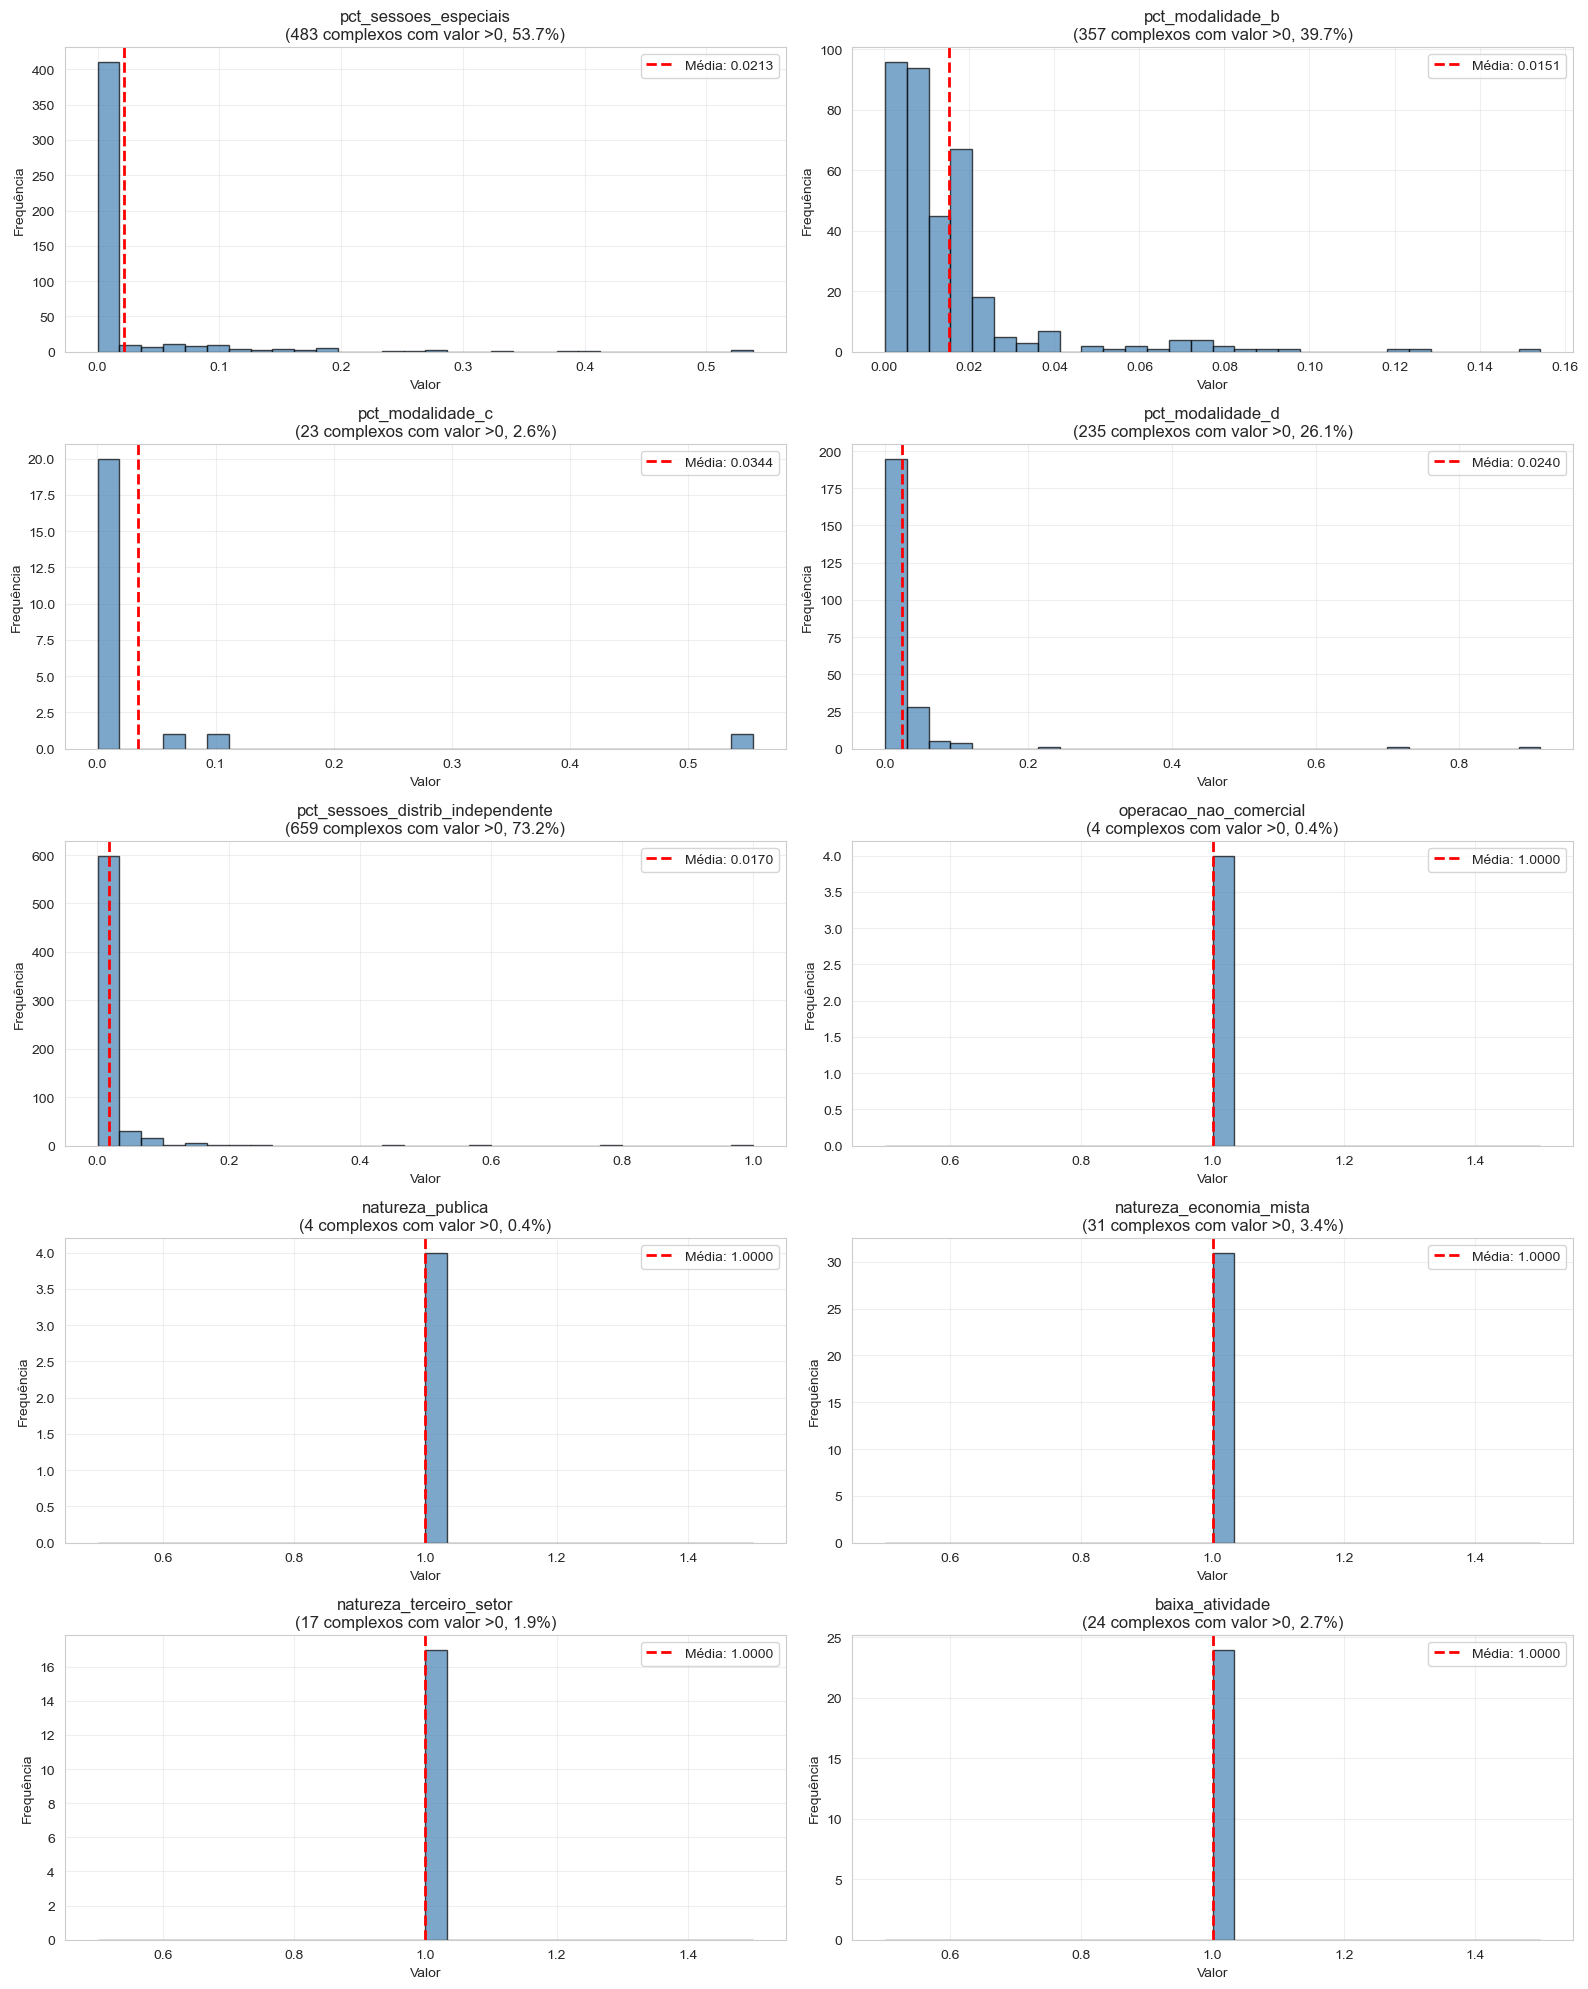

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import entropy

print("=" * 80)
print("ANÁLISE DETALHADA: Features com Baixa Variância")
print("=" * 80)

# ============================================
# 1. IDENTIFICAR FEATURES COM BAIXA VARIÂNCIA
# ============================================

print("\n" + "=" * 80)
print("1. IDENTIFICAÇÃO DE FEATURES COM BAIXA VARIÂNCIA")
print("=" * 80)

# Features suspeitas (percentuais e flags)
features_suspeitas = [
    'pct_sessoes_especiais',
    'pct_modalidade_b',  # Pré-estreias
    'pct_modalidade_c',  # Mostras/Festivais
    'pct_modalidade_d',  # Sessões Privadas
    'pct_sessoes_distrib_independente',
    'operacao_nao_comercial',
    'natureza_publica',
    'natureza_economia_mista',
    'natureza_terceiro_setor',
    'baixa_atividade',
]

# Calcular estatísticas
resultados = []

for feat in features_suspeitas:
    if feat in df_complexos.columns:
        serie = df_complexos[feat]
        
        # Estatísticas básicas
        n_zeros = (serie == 0).sum()
        pct_zeros = (n_zeros / len(serie)) * 100
        n_positivos = (serie > 0).sum()
        pct_positivos = (n_positivos / len(serie)) * 100
        
        # Valor médio, mediana, máximo
        media = serie.mean()
        mediana = serie.median()
        maximo = serie.max()
        std = serie.std()
        
        # Coeficiente de variação (CV = std/mean)
        cv = (std / media * 100) if media > 0 else 0
        
        resultados.append({
            'Feature': feat,
            'N_Zeros': n_zeros,
            '% Zeros': pct_zeros,
            'N_Positivos': n_positivos,
            '% Positivos': pct_positivos,
            'Média': media,
            'Mediana': mediana,
            'Máximo': maximo,
            'Std': std,
            'CV%': cv
        })

df_variancia = pd.DataFrame(resultados)

# Ordenar por % de zeros (decrescente)
df_variancia = df_variancia.sort_values('% Zeros', ascending=False)

print("\nTabela Resumo:")
print(df_variancia.to_string(index=False))

# ============================================
# 2. ANÁLISE INDIVIDUAL DETALHADA
# ============================================

print("\n" + "=" * 80)
print("2. ANÁLISE DETALHADA POR FEATURE")
print("=" * 80)

for feat in features_suspeitas:
    if feat not in df_complexos.columns:
        continue
        
    print(f"\n{'─'*80}")
    print(f"FEATURE: {feat}")
    print(f"{'─'*80}")
    
    serie = df_complexos[feat]
    
    # Estatísticas básicas
    print(f"\n📊 Estatísticas Básicas:")
    print(f"  • Total de complexos: {len(serie)}")
    print(f"  • Zeros: {(serie == 0).sum()} ({(serie == 0).sum()/len(serie)*100:.1f}%)")
    print(f"  • Positivos: {(serie > 0).sum()} ({(serie > 0).sum()/len(serie)*100:.1f}%)")
    print(f"  • Média: {serie.mean():.4f}")
    print(f"  • Mediana: {serie.median():.4f}")
    print(f"  • Std: {serie.std():.4f}")
    print(f"  • Mín: {serie.min():.4f} | Máx: {serie.max():.4f}")
    
    # Distribuição dos valores positivos
    if (serie > 0).sum() > 0:
        positivos = serie[serie > 0]
        print(f"\n📈 Distribuição dos Valores POSITIVOS:")
        print(f"  • N: {len(positivos)}")
        print(f"  • Média: {positivos.mean():.4f}")
        print(f"  • Mediana: {positivos.median():.4f}")
        print(f"  • Q1: {positivos.quantile(0.25):.4f}")
        print(f"  • Q3: {positivos.quantile(0.75):.4f}")
        print(f"  • Mín: {positivos.min():.4f} | Máx: {positivos.max():.4f}")
        
        # Percentis
        print(f"\n  Percentis dos positivos:")
        for p in [10, 25, 50, 75, 90, 95, 99]:
            val = positivos.quantile(p/100)
            print(f"    P{p}: {val:.4f}")
    
    # Top 10 complexos com maiores valores
    if (serie > 0).sum() > 0:
        print(f"\n🏆 TOP 10 Complexos com maiores valores:")
        top_complexos = df_complexos[serie > 0].nlargest(10, feat)
        
        colunas_exibir = ['municipio', 'UF', feat, 'total_sessoes', 'e_capital']
        print(top_complexos[colunas_exibir].to_string(index=False))
    
    # Análise por Capital vs Interior
    if 'e_capital' in df_complexos.columns:
        print(f"\n🌍 Análise Capital vs Interior:")
        
        capital_mean = serie[df_complexos['e_capital'] == 1].mean()
        interior_mean = serie[df_complexos['e_capital'] == 0].mean()
        
        capital_positivos = (serie[df_complexos['e_capital'] == 1] > 0).sum()
        interior_positivos = (serie[df_complexos['e_capital'] == 0] > 0).sum()
        
        capital_total = (df_complexos['e_capital'] == 1).sum()
        interior_total = (df_complexos['e_capital'] == 0).sum()
        
        print(f"  Capital:")
        print(f"    • Média: {capital_mean:.4f}")
        print(f"    • Com valores >0: {capital_positivos}/{capital_total} ({capital_positivos/capital_total*100:.1f}%)")
        
        print(f"  Interior:")
        print(f"    • Média: {interior_mean:.4f}")
        print(f"    • Com valores >0: {interior_positivos}/{interior_total} ({interior_positivos/interior_total*100:.1f}%)")
        
        if capital_mean > 0 or interior_mean > 0:
            diferenca = capital_mean - interior_mean
            print(f"  → Diferença: {diferenca:+.4f} (Capital - Interior)")

# ============================================
# 3. VISUALIZAÇÕES
# ============================================

print("\n" + "=" * 80)
print("3. GERANDO VISUALIZAÇÕES")
print("=" * 80)

# Configurar estilo
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 12)

# Criar subplots
fig, axes = plt.subplots(5, 2, figsize=(16, 20))
axes = axes.ravel()

for idx, feat in enumerate(features_suspeitas):
    if feat not in df_complexos.columns or idx >= len(axes):
        continue
    
    ax = axes[idx]
    serie = df_complexos[feat]
    
    # Histograma apenas dos valores positivos
    if (serie > 0).sum() > 0:
        positivos = serie[serie > 0]
        ax.hist(positivos, bins=30, color='steelblue', alpha=0.7, edgecolor='black')
        ax.set_xlabel('Valor')
        ax.set_ylabel('Frequência')
        ax.set_title(f'{feat}\n({len(positivos)} complexos com valor >0, {len(positivos)/len(serie)*100:.1f}%)')
        ax.grid(True, alpha=0.3)
        
        # Adicionar linha da média
        ax.axvline(positivos.mean(), color='red', linestyle='--', linewidth=2, label=f'Média: {positivos.mean():.4f}')
        ax.legend()
    else:
        ax.text(0.5, 0.5, 'Todos zeros', ha='center', va='center', fontsize=14)
        ax.set_title(f'{feat}\n(100% zeros)')
        ax.set_xticks([])
        ax.set_yticks([])

plt.tight_layout()
plt.savefig('../Outputs/analise_baixa_variancia_histogramas.png', dpi=150, bbox_inches='tight')
print("\n✓ Histogramas salvos: analise_baixa_variancia_histogramas.png")

# ============================================
# 4. MATRIZ DE CORRELAÇÃO (entre features suspeitas)
# ============================================

print("\n" + "=" * 80)
print("4. CORRELAÇÃO ENTRE FEATURES SUSPEITAS")
print("=" * 80)

features_existentes = [f for f in features_suspeitas if f in df_complexos.columns]
df_subset = df_complexos[features_existentes]

# Calcular correlação
corr_matrix = df_subset.corr()

# Plotar
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlação entre Features com Baixa Variância', fontsize=14, pad=20)
plt.tight_layout()
plt.savefig('../Outputs/analise_baixa_variancia_correlacao.png', dpi=150, bbox_inches='tight')
print("\n✓ Matriz de correlação salva: analise_baixa_variancia_correlacao.png")

# ============================================
# 5. ANÁLISE DE CO-OCORRÊNCIA
# ============================================

print("\n" + "=" * 80)
print("5. CO-OCORRÊNCIA: Complexos com múltiplas features raras")
print("=" * 80)

# Criar flags binárias (>0 ou não)
df_flags = pd.DataFrame()
for feat in features_existentes:
    df_flags[f'{feat}_flag'] = (df_complexos[feat] > 0).astype(int)

# Contar quantas features raras cada complexo tem
df_complexos['num_features_raras'] = df_flags.sum(axis=1)

print("\nDistribuição de complexos por número de features raras:")
print(df_complexos['num_features_raras'].value_counts().sort_index())

# Complexos com múltiplas features raras
print("\n🔍 Complexos com 3+ features raras:")
complexos_multi_raras = df_complexos[df_complexos['num_features_raras'] >= 3]

if len(complexos_multi_raras) > 0:
    colunas_exibir = ['municipio', 'UF', 'num_features_raras', 'total_sessoes', 
                      'pct_sessoes_brasileiras', 'num_obras_exclusivas', 'e_capital']
    print(complexos_multi_raras[colunas_exibir].sort_values('num_features_raras', ascending=False).head(20).to_string(index=False))
    
    # Quais features raras eles têm?
    print("\n📋 Detalhamento das features raras nesses complexos:")
    for idx, row in complexos_multi_raras.head(10).iterrows():
        print(f"\n  {row['municipio']}/{row['UF']} ({row['num_features_raras']} features raras):")
        for feat in features_existentes:
            if row[feat] > 0:
                print(f"    • {feat}: {row[feat]:.4f}")
else:
    print("  Nenhum complexo com 3+ features raras")

# ============================================
# 6. PODER DISCRIMINATÓRIO
# ============================================

print("\n" + "=" * 80)
print("6. AVALIAÇÃO DE PODER DISCRIMINATÓRIO")
print("=" * 80)

print("\n📊 Critérios para MANTER uma feature com baixa variância:\n")

criterios = []

for feat in features_existentes:
    serie = df_complexos[feat]
    pct_positivos = (serie > 0).sum() / len(serie) * 100
    
    # Critério 1: Pelo menos 5% de valores positivos
    criterio_1 = pct_positivos >= 5
    
    # Critério 2: Variação significativa entre Capital e Interior
    if 'e_capital' in df_complexos.columns:
        capital_mean = serie[df_complexos['e_capital'] == 1].mean()
        interior_mean = serie[df_complexos['e_capital'] == 0].mean()
        diferenca_relativa = abs(capital_mean - interior_mean) / max(capital_mean, interior_mean, 1e-10)
        criterio_2 = diferenca_relativa > 0.5  # Diferença >50%
    else:
        criterio_2 = False
    
    # Critério 3: Máximo valor alto (>10% para percentuais)
    if feat.startswith('pct_'):
        criterio_3 = serie.max() > 0.10
    else:
        criterio_3 = serie.max() > 0
    
    # Critério 4: Std relativamente alto (>1% da média para não-zeros)
    if (serie > 0).sum() > 0:
        positivos = serie[serie > 0]
        cv = positivos.std() / positivos.mean() if positivos.mean() > 0 else 0
        criterio_4 = cv > 0.5
    else:
        criterio_4 = False
    
    # Decisão
    manter = criterio_1 or (criterio_2 and criterio_3) or criterio_4
    
    criterios.append({
        'Feature': feat,
        '% Positivos': pct_positivos,
        'Critério 1 (≥5%)': '✓' if criterio_1 else '✗',
        'Critério 2 (Cap≠Int)': '✓' if criterio_2 else '✗',
        'Critério 3 (Max>10%)': '✓' if criterio_3 else '✗',
        'Critério 4 (CV>0.5)': '✓' if criterio_4 else '✗',
        'DECISÃO': '✅ MANTER' if manter else '❌ REMOVER'
    })

df_criterios = pd.DataFrame(criterios)
print(df_criterios.to_string(index=False))

# ============================================
# 7. RECOMENDAÇÃO FINAL
# ============================================

print("\n" + "=" * 80)
print("7. RECOMENDAÇÃO FINAL")
print("=" * 80)

manter = df_criterios[df_criterios['DECISÃO'] == '✅ MANTER']['Feature'].tolist()
remover = df_criterios[df_criterios['DECISÃO'] == '❌ REMOVER']['Feature'].tolist()

print(f"\n✅ MANTER ({len(manter)} features):")
for feat in manter:
    pct = df_criterios[df_criterios['Feature'] == feat]['% Positivos'].values[0]
    print(f"  • {feat:45s} ({pct:.1f}% positivos)")

print(f"\n❌ REMOVER ({len(remover)} features):")
for feat in remover:
    pct = df_criterios[df_criterios['Feature'] == feat]['% Positivos'].values[0]
    print(f"  • {feat:45s} ({pct:.1f}% positivos)")

print("\n" + "=" * 80)
print("✓ Análise completa!")
print("=" * 80)

# Limpar variável temporária
df_complexos = df_complexos.drop(['num_features_raras'], axis=1)


In [42]:
print("=" * 80)
print("VERIFICAÇÃO: Head vs Dataset Completo")
print("=" * 80)

# Features suspeitas
features_check = [
    'pct_sessoes_especiais',
    'pct_sessoes_distrib_independente',
    'pct_modalidade_b',
    'pct_modalidade_c',
    'pct_modalidade_d',
]

print("\n1. VALORES NO HEAD(5):")
print(df_complexos[features_check].head(5))

print("\n2. ESTATÍSTICAS DO DATASET COMPLETO:")
for feat in features_check:
    n_zeros = (df_complexos[feat] == 0).sum()
    n_positivos = (df_complexos[feat] > 0).sum()
    pct_positivos = (n_positivos / len(df_complexos)) * 100
    
    print(f"\n{feat}:")
    print(f"  • Zeros: {n_zeros} ({n_zeros/len(df_complexos)*100:.1f}%)")
    print(f"  • Positivos: {n_positivos} ({pct_positivos:.1f}%)")
    print(f"  • Média: {df_complexos[feat].mean():.6f}")
    print(f"  • Máximo: {df_complexos[feat].max():.6f}")

print("\n3. VALORES EM HEAD(5) especificamente:")
for feat in features_check:
    valores_head = df_complexos[feat].head(5).tolist()
    print(f"{feat}: {valores_head}")

print("\n4. AMOSTRA ALEATÓRIA (10 complexos):")
amostra_random = df_complexos[features_check].sample(10, random_state=42)
print(amostra_random)

print("\n5. OS 5 PRIMEIROS vs OS 5 ÚLTIMOS:")
print("\nPrimeiros 5:")
print(df_complexos[['REGISTRO_COMPLEXO', 'municipio'] + features_check].head(5))
print("\nÚltimos 5:")
print(df_complexos[['REGISTRO_COMPLEXO', 'municipio'] + features_check].tail(5))

print("\n" + "=" * 80)

VERIFICAÇÃO: Head vs Dataset Completo

1. VALORES NO HEAD(5):
   pct_sessoes_especiais  pct_sessoes_distrib_independente  pct_modalidade_b  \
0               0.001479                          0.004931          0.000000   
1               0.000000                          0.000000          0.000000   
2               0.002525                          0.004512          0.000000   
3               0.000000                          0.000000          0.015340   
4               0.000000                          0.003453          0.000197   

   pct_modalidade_c  pct_modalidade_d  
0               0.0          0.000000  
1               0.0          0.000000  
2               0.0          0.000000  
3               0.0          0.000959  
4               0.0          0.000000  

2. ESTATÍSTICAS DO DATASET COMPLETO:

pct_sessoes_especiais:
  • Zeros: 417 (46.3%)
  • Positivos: 483 (53.7%)
  • Média: 0.011454
  • Máximo: 0.538490

pct_sessoes_distrib_independente:
  • Zeros: 241 (26.8%)
  • Po

In [44]:
print("Investigando co-ocorrência de operacao_nao_comercial:\n")

# Filtrar os 4 complexos não comerciais
nao_comerciais = df_complexos[df_complexos['operacao_nao_comercial'] == 1]

print("Os 4 complexos não comerciais:")
colunas_check = [
    'municipio', 'UF', 'operacao_nao_comercial',
    'natureza_publica', 'natureza_economia_mista', 'natureza_terceiro_setor',
    'natureza_privada_com_fins_lucrativos', 'natureza_nao_informada',
    'total_sessoes', 'pct_modalidade_c', 'num_obras_exclusivas'
]

print(nao_comerciais[colunas_check].to_string(index=False))

# Verificar se há sobreposição COMPLETA
print("\n\nVerificação de sobreposição:")
print(f"operacao_nao_comercial = 1 E natureza_publica = 1: {((df_complexos['operacao_nao_comercial']==1) & (df_complexos['natureza_publica']==1)).sum()}")
print(f"operacao_nao_comercial = 1 E natureza_terceiro_setor = 1: {((df_complexos['operacao_nao_comercial']==1) & (df_complexos['natureza_terceiro_setor']==1)).sum()}")
print(f"operacao_nao_comercial = 1 E natureza_privada = 1: {((df_complexos['operacao_nao_comercial']==1) & (df_complexos['natureza_privada_com_fins_lucrativos']==1)).sum()}")
print(f"operacao_nao_comercial = 1 E natureza_nao_informada = 1: {((df_complexos['operacao_nao_comercial']==1) & (df_complexos['natureza_nao_informada']==1)).sum()}")


Investigando co-ocorrência de operacao_nao_comercial:

Os 4 complexos não comerciais:
     municipio UF  operacao_nao_comercial  natureza_publica  natureza_economia_mista  natureza_terceiro_setor  natureza_privada_com_fins_lucrativos  natureza_nao_informada  total_sessoes  pct_modalidade_c  num_obras_exclusivas
     CAMPO BOM RS                       1                 0                        0                        0                                     0                       1           1386          0.000000                     0
     SÃO PAULO SP                       1                 0                        0                        1                                     0                       0            735          0.000000                    28
RIO DE JANEIRO RJ                       1                 0                        0                        1                                     0                       0            171          0.000000                     0
     S

In [47]:
print("=" * 80)
print("CRIANDO FEATURE AGREGADA: natureza_nao_privada")
print("=" * 80)

# Criar flag agregada (Python correto)
df_complexos['natureza_nao_privada'] = (
    (df_complexos['natureza_publica'] == 1) | 
    (df_complexos['natureza_economia_mista'] == 1) | 
    (df_complexos['natureza_terceiro_setor'] == 1)
).astype(int)

print(f"\n✓ Feature criada: natureza_nao_privada")
print(f"  Total de complexos não-privados: {df_complexos['natureza_nao_privada'].sum()} ({df_complexos['natureza_nao_privada'].sum()/len(df_complexos)*100:.1f}%)")

# Verificar distribuição
print(f"\nDistribuição:")
print(f"  Privada (implícito): {(df_complexos['natureza_nao_privada']==0).sum()} ({(df_complexos['natureza_nao_privada']==0).sum()/len(df_complexos)*100:.1f}%)")
print(f"  Não-privada: {(df_complexos['natureza_nao_privada']==1).sum()} ({(df_complexos['natureza_nao_privada']==1).sum()/len(df_complexos)*100:.1f}%)")

# Verificar os 4 casos de operacao_nao_comercial
print(f"\n" + "=" * 80)
print("VALIDAÇÃO: Como ficam os 4 casos não-comerciais?")
print("=" * 80)

nao_comerciais = df_complexos[df_complexos['operacao_nao_comercial'] == 1]
print(nao_comerciais[['municipio', 'UF', 'operacao_nao_comercial', 'natureza_nao_privada', 
                       'natureza_nao_informada', 'total_sessoes', 'pct_modalidade_c', 'num_obras_exclusivas']].to_string(index=False))

print(f"\n📊 Análise dos 4 casos:")
print(f"  • Capturados por natureza_nao_privada: {(nao_comerciais['natureza_nao_privada']==1).sum()} de 4")
print(f"  • NÃO capturados (Campo Bom/RS): {(nao_comerciais['natureza_nao_privada']==0).sum()} de 4")

# Verificar caso especial Campo Bom
campo_bom = df_complexos[(df_complexos['municipio'] == 'CAMPO BOM') & (df_complexos['UF'] == 'RS')]
if len(campo_bom) > 0:
    print(f"\n🔍 Caso especial - Campo Bom/RS:")
    print(f"  • operacao_nao_comercial: {campo_bom['operacao_nao_comercial'].values[0]}")
    print(f"  • natureza_nao_privada: {campo_bom['natureza_nao_privada'].values[0]}")
    print(f"  • natureza_nao_informada: {campo_bom['natureza_nao_informada'].values[0]}")
    print(f"  → Combinação ÚNICA: não-comercial + não-informada (sem ser não-privada)")

print(f"\n" + "=" * 80)
print("✓ Validação completa")
print("=" * 80)

CRIANDO FEATURE AGREGADA: natureza_nao_privada

✓ Feature criada: natureza_nao_privada
  Total de complexos não-privados: 52 (5.8%)

Distribuição:
  Privada (implícito): 848 (94.2%)
  Não-privada: 52 (5.8%)

VALIDAÇÃO: Como ficam os 4 casos não-comerciais?
     municipio UF  operacao_nao_comercial  natureza_nao_privada  natureza_nao_informada  total_sessoes  pct_modalidade_c  num_obras_exclusivas
     CAMPO BOM RS                       1                     0                       1           1386          0.000000                     0
     SÃO PAULO SP                       1                     1                       0            735          0.000000                    28
RIO DE JANEIRO RJ                       1                     1                       0            171          0.000000                     0
     SÃO PAULO SP                       1                     1                       0           1795          0.555432                    39

📊 Análise dos 4 casos:
  • 